# Multi-Armed Bandit Simulation: Optimizing Financial Aid Discount Rates

This notebook models a tuition-dependent institution using contextual multi-armed bandits to learn
the optimal institutional aid (discount rate) to offer admitted students. The key insight: the
**revenue-maximizing** discount is not the **yield-maximizing** discount. Higher discounts increase
enrollment probability but reduce net tuition per enrolled student — creating a non-trivial optimization problem.

**Structure:**
1. Imports & Configuration
2. Enrollment Model
3. Insight Plots
4. Bandit Algorithms
5. Experiment Runner
6. Results & Visualization
7. Discussion

## 1. Imports & Configuration

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 15,
    'axes.labelsize': 13,
    'legend.fontsize': 11,
    'figure.dpi': 110,
})

# Colour palette
SEG_COLORS  = ['#E74C3C', '#3498DB', '#2ECC71']   # one per segment
ALG_COLORS  = {'EpsilonGreedy': '#9B59B6', 'UCB1': '#E67E22', 'ThompsonSampling': '#1ABC9C'}
ALG_LABELS  = {'EpsilonGreedy': 'ε-Greedy', 'UCB1': 'UCB1', 'ThompsonSampling': 'Thompson'}
ALG_NAMES   = ['EpsilonGreedy', 'UCB1', 'ThompsonSampling']

CONFIG = {
    'tuition'       : 50_000,
    'discount_rates': [0.20, 0.30, 0.40, 0.50, 0.60],
    'arm_labels'    : ['20%', '30%', '40%', '50%', '60%'],
    'n_arms'        : 5,
    'n_admits'      : 5_000,
    'n_runs'        : 30,
    'seed'          : 42,
    'segments': [
        {'name': 'High-Need',     'proportion': 0.40, 'floor': 0.05, 'ceiling': 0.85, 'midpoint': 0.40, 'k': 15},
        {'name': 'Merit-Focused', 'proportion': 0.35, 'floor': 0.15, 'ceiling': 0.70, 'midpoint': 0.35, 'k': 10},
        {'name': 'Low-Need',      'proportion': 0.25, 'floor': 0.25, 'ceiling': 0.55, 'midpoint': 0.30, 'k':  8},
    ],
    'epsilon': 0.1,
    'ucb_c'  : 2.0,
}

np.random.seed(CONFIG['seed'])
print('Configuration loaded.')
print(f"Arms (discount rates): {CONFIG['discount_rates']}")
net_revs = [f"${CONFIG['tuition'] * (1-d):,.0f}" for d in CONFIG['discount_rates']]
print(f'Net revenue per enrolled student: {net_revs}')

Configuration loaded.
Arms (discount rates): [0.2, 0.3, 0.4, 0.5, 0.6]
Net revenue per enrolled student: ['$40,000', '$35,000', '$30,000', '$25,000', '$20,000']


## 2. Enrollment Model

Enrollment probability follows a logistic curve:
$$P(\text{enroll}) = \text{floor} + \frac{\text{ceiling} - \text{floor}}{1 + e^{-k(\text{discount} - \text{midpoint})}}$$

The reward for a single offer is a Bernoulli draw times net tuition:
$$\text{reward} = \mathbf{1}[\text{enrolled}] \times \text{tuition} \times (1 - \text{discount})$$

In [11]:
def enrollment_prob(discount, floor, ceiling, midpoint, k):
    """Logistic enrollment probability given discount and segment parameters."""
    return floor + (ceiling - floor) / (1.0 + np.exp(-k * (discount - midpoint)))

def expected_revenue(discount, tuition, floor, ceiling, midpoint, k):
    """Expected net revenue per offer: P(enroll) * tuition * (1 - discount)."""
    p = enrollment_prob(discount, floor, ceiling, midpoint, k)
    return p * tuition * (1.0 - discount)

def get_true_optimal(seg, config):
    """Return (best_arm_index, list_of_expected_revenues_per_arm)."""
    revs = [expected_revenue(d, config['tuition'],
                             seg['floor'], seg['ceiling'],
                             seg['midpoint'], seg['k'])
            for d in config['discount_rates']]
    return int(np.argmax(revs)), revs

# ── Compute and display true optima ──────────────────────────────────────────
print('True Optimal Arms by Segment')
print('=' * 72)
TRUE_OPTIMAL = []   # store for later use
TRUE_REVENUES = []  # expected revenue per arm per segment

for seg in CONFIG['segments']:
    opt_arm, revs = get_true_optimal(seg, CONFIG)
    TRUE_OPTIMAL.append(opt_arm)
    TRUE_REVENUES.append(revs)
    opt_d = CONFIG['discount_rates'][opt_arm]
    p_opt = enrollment_prob(opt_d, seg['floor'], seg['ceiling'], seg['midpoint'], seg['k'])
    rev_str = [f'${r:,.0f}' for r in revs]
    print(f"\n{seg['name']} ({seg['proportion']*100:.0f}% of admits):")
    print(f'  E[revenue] per arm: {rev_str}')
    print(f'  Optimal → Arm {opt_arm} ({opt_d*100:.0f}% discount) | '
          f'P(enroll)={p_opt:.3f} | E[rev]=${revs[opt_arm]:,.0f}')

# ── Sanity check: High-Need values match spec ─────────────────────────────────
print('\nSanity check — High-Need expected revenues (spec: ~$3200, $5250, $11400, $18000, $16400):')
hn = CONFIG['segments'][0]
for arm, (d, rev) in enumerate(zip(CONFIG['discount_rates'], TRUE_REVENUES[0])):
    print(f'  Arm {arm} ({int(d*100)}%): ${rev:,.0f}')

True Optimal Arms by Segment

High-Need (40% of admits):
  E[revenue] per arm: ['$3,518', '$6,858', '$13,500', '$17,601', '$16,241']
  Optimal → Arm 3 (50% discount) | P(enroll)=0.704 | E[rev]=$17,601

Merit-Focused (35% of admits):
  E[revenue] per arm: ['$10,013', '$12,518', '$14,771', '$14,992', '$13,166']
  Optimal → Arm 3 (50% discount) | P(enroll)=0.600 | E[rev]=$14,992

Low-Need (25% of admits):
  E[revenue] per arm: ['$13,720', '$14,000', '$13,710', '$12,490', '$10,501']
  Optimal → Arm 1 (30% discount) | P(enroll)=0.400 | E[rev]=$14,000

Sanity check — High-Need expected revenues (spec: ~$3200, $5250, $11400, $18000, $16400):
  Arm 0 (20%): $3,518
  Arm 1 (30%): $6,858
  Arm 2 (40%): $13,500
  Arm 3 (50%): $17,601
  Arm 4 (60%): $16,241


## 3. Insight Plots

Before running any bandit, we visualise the underlying enrollment model to build intuition
about why the optimal discount differs by segment and is **not** the highest discount.

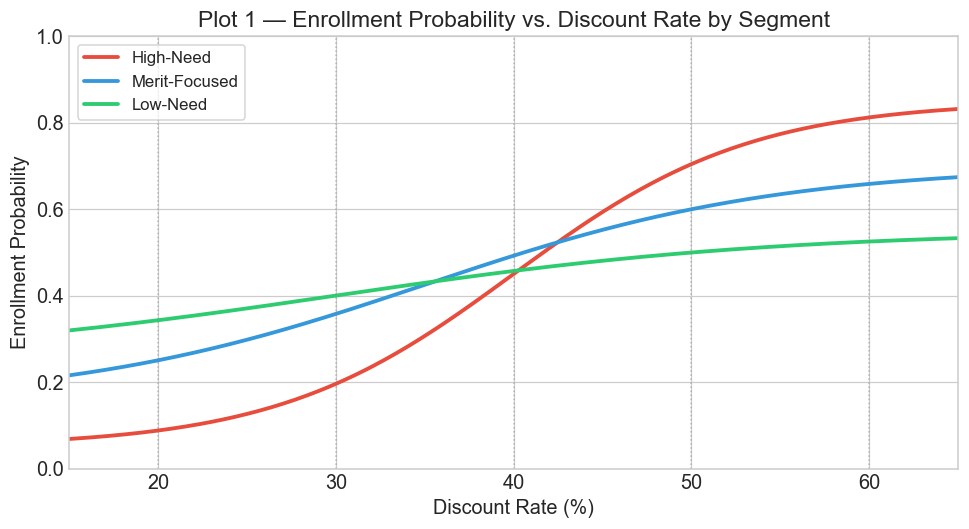

High-Need students require large discounts to enroll; Low-Need are relatively inelastic.


In [12]:
# Plot 1: Enrollment Probability Curves
discounts_fine = np.linspace(0.15, 0.65, 300)

fig, ax = plt.subplots(figsize=(9, 5))
for seg, color in zip(CONFIG['segments'], SEG_COLORS):
    probs = [enrollment_prob(d, seg['floor'], seg['ceiling'], seg['midpoint'], seg['k'])
             for d in discounts_fine]
    ax.plot(discounts_fine * 100, probs, color=color, linewidth=2.5, label=seg['name'])

# Mark the five arm positions
for d in CONFIG['discount_rates']:
    ax.axvline(d * 100, color='gray', linestyle=':', alpha=0.45, linewidth=1)

ax.set_xlabel('Discount Rate (%)')
ax.set_ylabel('Enrollment Probability')
ax.set_title('Plot 1 — Enrollment Probability vs. Discount Rate by Segment')
ax.legend(frameon=True, loc='upper left')
ax.set_xlim(15, 65)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()
print('High-Need students require large discounts to enroll; Low-Need are relatively inelastic.')

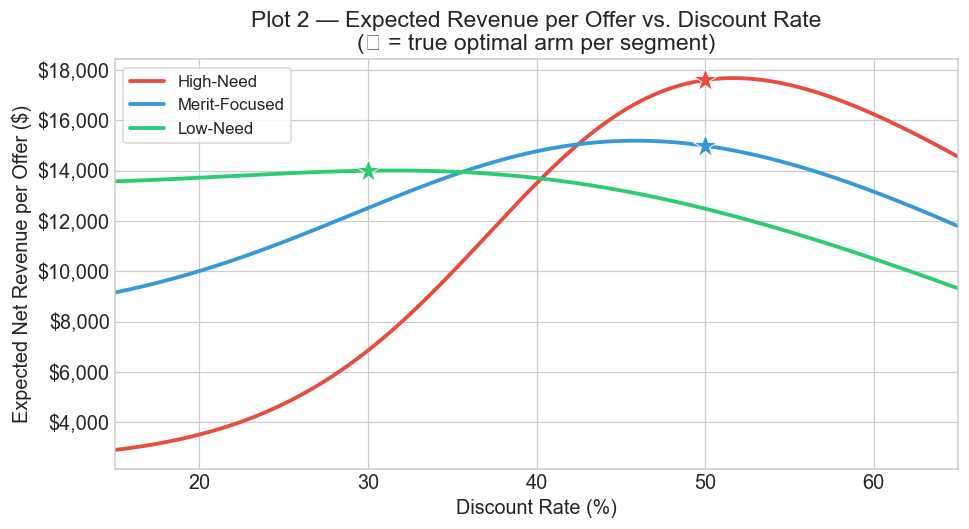

Key insight: revenue peaks differ by segment, and none peak at the highest discount (60%).


In [13]:
# Plot 2: Expected Revenue Curves
fig, ax = plt.subplots(figsize=(9, 5))

for seg, color in zip(CONFIG['segments'], SEG_COLORS):
    opt_arm, revs = get_true_optimal(seg, CONFIG)
    rev_curve = [expected_revenue(d, CONFIG['tuition'],
                                  seg['floor'], seg['ceiling'],
                                  seg['midpoint'], seg['k'])
                 for d in discounts_fine]
    ax.plot(discounts_fine * 100, rev_curve, color=color, linewidth=2.5, label=seg['name'])
    # Star at optimal arm
    opt_d   = CONFIG['discount_rates'][opt_arm]
    opt_rev = revs[opt_arm]
    ax.plot(opt_d * 100, opt_rev, '*', color=color, markersize=16, zorder=5,
            markeredgecolor='white', markeredgewidth=0.6)

ax.set_xlabel('Discount Rate (%)')
ax.set_ylabel('Expected Net Revenue per Offer ($)')
ax.set_title('Plot 2 — Expected Revenue per Offer vs. Discount Rate\n(★ = true optimal arm per segment)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(frameon=True, loc='upper left')
ax.set_xlim(15, 65)
plt.tight_layout()
plt.show()
print('Key insight: revenue peaks differ by segment, and none peak at the highest discount (60%).')

## 4. Bandit Algorithms

All three algorithms share a base class that tracks per-(segment, arm) counts and running means.
Setting `contextual=True` maintains separate statistics for each student segment; `contextual=False`
pools all students into a single shared policy.

| Algorithm | Exploration strategy |
|-----------|---------------------|
| ε-Greedy | Random arm with probability ε = 0.1 |
| UCB1 | Optimistic confidence bound: μ̂ + c√(ln t / nₐ), c = 2 |
| Thompson Sampling | Sample from Normal posterior (Welford online variance) |

In [14]:
class BanditBase:
    """Base class for contextual and non-contextual bandits."""

    def __init__(self, n_arms, n_segments=1, contextual=False):
        self.n_arms     = n_arms
        self.n_segments = n_segments
        self.contextual = contextual
        self.reset()

    def reset(self):
        shape = (self.n_segments, self.n_arms) if self.contextual else (1, self.n_arms)
        self.counts = np.zeros(shape, dtype=int)
        self.means  = np.zeros(shape, dtype=float)
        self._extra_reset()

    def _extra_reset(self):
        pass

    def _row(self, segment):
        """Return the statistics row index for the given segment."""
        return segment if self.contextual else 0

    def select_arm(self, segment):
        raise NotImplementedError

    def update(self, segment, arm, reward):
        r = self._row(segment)
        self.counts[r, arm] += 1
        n = self.counts[r, arm]
        # Online mean update (Welford step 1)
        self.means[r, arm] += (reward - self.means[r, arm]) / n


class EpsilonGreedy(BanditBase):
    def __init__(self, n_arms, n_segments, contextual, epsilon=0.1):
        self.epsilon = epsilon
        super().__init__(n_arms, n_segments, contextual)

    def select_arm(self, segment):
        r = self._row(segment)
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_arms)
        return int(np.argmax(self.means[r]))


class UCB1(BanditBase):
    def __init__(self, n_arms, n_segments, contextual, c=2.0):
        self.c = c
        super().__init__(n_arms, n_segments, contextual)

    def _extra_reset(self):
        n_rows = self.n_segments if self.contextual else 1
        self.total = np.zeros(n_rows, dtype=int)

    def select_arm(self, segment):
        r = self._row(segment)
        # Pull each arm once before using UCB scores
        unpulled = np.where(self.counts[r] == 0)[0]
        if len(unpulled) > 0:
            return int(unpulled[0])
        ucb = self.means[r] + self.c * np.sqrt(np.log(self.total[r]) / self.counts[r])
        return int(np.argmax(ucb))

    def update(self, segment, arm, reward):
        r = self._row(segment)
        self.total[r] += 1
        super().update(segment, arm, reward)


class ThompsonSampling(BanditBase):
    """
    Normal posterior bandit using Welford's online algorithm to maintain
    per-(segment, arm) running mean and variance.

    Posterior of the mean: Normal(mu_hat, sigma^2 / n)
    where sigma^2 = M2 / (n-1) is the sample variance.
    """

    def _extra_reset(self):
        shape = (self.n_segments, self.n_arms) if self.contextual else (1, self.n_arms)
        self.M2 = np.zeros(shape, dtype=float)  # sum of squared deviations

    def select_arm(self, segment):
        r = self._row(segment)
        samples = np.empty(self.n_arms)
        for arm in range(self.n_arms):
            n = self.counts[r, arm]
            if n < 2:
                # Wide uninformative prior; ensures early exploration
                samples[arm] = np.random.normal(0.0, 1e6)
            else:
                sample_var = self.M2[r, arm] / (n - 1)
                std_of_mean = np.sqrt(max(sample_var, 1.0) / n)
                samples[arm] = np.random.normal(self.means[r, arm], std_of_mean)
        return int(np.argmax(samples))

    def update(self, segment, arm, reward):
        r = self._row(segment)
        mean_old = self.means[r, arm]          # capture before base update
        super().update(segment, arm, reward)    # increments counts, updates mean
        mean_new = self.means[r, arm]
        # Welford M2 accumulation: M2 += (x - mean_old) * (x - mean_new)
        self.M2[r, arm] += (reward - mean_old) * (reward - mean_new)


def make_bandits(config, contextual):
    n_arms = config['n_arms']
    n_segs = len(config['segments'])
    return {
        'EpsilonGreedy'   : EpsilonGreedy(n_arms, n_segs, contextual, epsilon=config['epsilon']),
        'UCB1'            : UCB1(n_arms, n_segs, contextual, c=config['ucb_c']),
        'ThompsonSampling': ThompsonSampling(n_arms, n_segs, contextual),
    }

print('BanditBase, EpsilonGreedy, UCB1, ThompsonSampling defined.')

BanditBase, EpsilonGreedy, UCB1, ThompsonSampling defined.


## 5. Experiment Runner

`run_simulation` runs one full cycle of 5,000 admits for all three algorithms and returns per-step
rewards, cumulative revenue, cumulative regret, and arm-selection history.

The **oracle** always picks the true optimal arm for the arriving student's segment — it serves
as the regret baseline. **Regret** is the gap between oracle cumulative revenue and algorithm
cumulative revenue.

In [15]:
def run_simulation(config, contextual, rng):
    """
    Run one simulation of n_admits rounds for all three algorithms.

    Returns
    -------
    results      : dict[alg_name -> dict]
    oracle_cumrev: ndarray of shape (n_admits,)
    """
    n_admits   = config['n_admits']
    n_segs     = len(config['segments'])
    seg_props  = [s['proportion'] for s in config['segments']]

    # Draw student sequence once, shared across algorithms for fair comparison
    students = rng.choice(n_segs, size=n_admits, p=seg_props)

    # Oracle: always pulls the true optimal arm for each student
    oracle_rewards = np.array([
        TRUE_REVENUES[students[t]][TRUE_OPTIMAL[students[t]]]
        for t in range(n_admits)
    ])
    oracle_cumrev = np.cumsum(oracle_rewards)

    bandits = make_bandits(config, contextual)
    results = {}

    for name, bandit in bandits.items():
        bandit.reset()
        rewards      = np.zeros(n_admits)
        chosen_arms  = np.zeros(n_admits, dtype=int)

        for t in range(n_admits):
            seg_idx = students[t]
            seg     = config['segments'][seg_idx]
            arm     = bandit.select_arm(seg_idx)
            chosen_arms[t] = arm

            d       = config['discount_rates'][arm]
            p       = enrollment_prob(d, seg['floor'], seg['ceiling'], seg['midpoint'], seg['k'])
            enrolled = rng.random() < p
            reward  = float(enrolled) * config['tuition'] * (1.0 - d)
            rewards[t] = reward
            bandit.update(seg_idx, arm, reward)

        cumrev    = np.cumsum(rewards)
        cumregret = oracle_cumrev - cumrev

        results[name] = {
            'cumrev'     : cumrev,
            'cumregret'  : cumregret,
            'chosen_arms': chosen_arms,
            'students'   : students,
            'bandit'     : bandit,
        }

    return results, oracle_cumrev


def run_all_experiments(config):
    """
    Run n_runs independent simulations for both contextual and non-contextual modes.
    Returns a dict keyed by mode ('contextual' / 'non_contextual').
    """
    master_rng = np.random.default_rng(config['seed'])

    all_results = {}
    for contextual in [False, True]:
        mode = 'contextual' if contextual else 'non_contextual'
        print(f'\nRunning {mode} ({config["n_runs"]} runs)...')

        run_data   = {alg: {'cumrev': [], 'cumregret': [], 'chosen_arms': [], 'students': []}
                      for alg in ALG_NAMES}
        oracle_runs = []
        last_bandits = None  # save from final run for policy analysis

        for run in range(config['n_runs']):
            if (run + 1) % 10 == 0 or run == 0:
                print(f'  run {run+1}/{config["n_runs"]}')
            rng = np.random.default_rng(master_rng.integers(0, 2**31))
            results, oracle_cumrev = run_simulation(config, contextual, rng)
            oracle_runs.append(oracle_cumrev)

            for alg, res in results.items():
                run_data[alg]['cumrev'].append(res['cumrev'])
                run_data[alg]['cumregret'].append(res['cumregret'])
                run_data[alg]['chosen_arms'].append(res['chosen_arms'])
                run_data[alg]['students'].append(res['students'])
            last_bandits = {alg: results[alg]['bandit'] for alg in ALG_NAMES}

        all_results[mode] = {
            'run_data'    : run_data,
            'oracle_runs' : oracle_runs,
            'last_bandits': last_bandits,
        }

    print('\nAll experiments complete.')
    return all_results


def mean_ci(arrays, z=1.96):
    """Mean and 95 % CI across runs."""
    arr  = np.array(arrays)
    mu   = arr.mean(axis=0)
    ci   = z * arr.std(axis=0) / np.sqrt(arr.shape[0])
    return mu, ci

print('run_simulation, run_all_experiments, mean_ci defined.')

run_simulation, run_all_experiments, mean_ci defined.


In [16]:
# Run all 30 × 2-mode experiments (~1–2 min)
ALL_RESULTS = run_all_experiments(CONFIG)


Running non_contextual (30 runs)...
  run 1/30
  run 10/30
  run 20/30
  run 30/30

Running contextual (30 runs)...
  run 1/30
  run 10/30
  run 20/30
  run 30/30

All experiments complete.


## 6. Results & Visualization

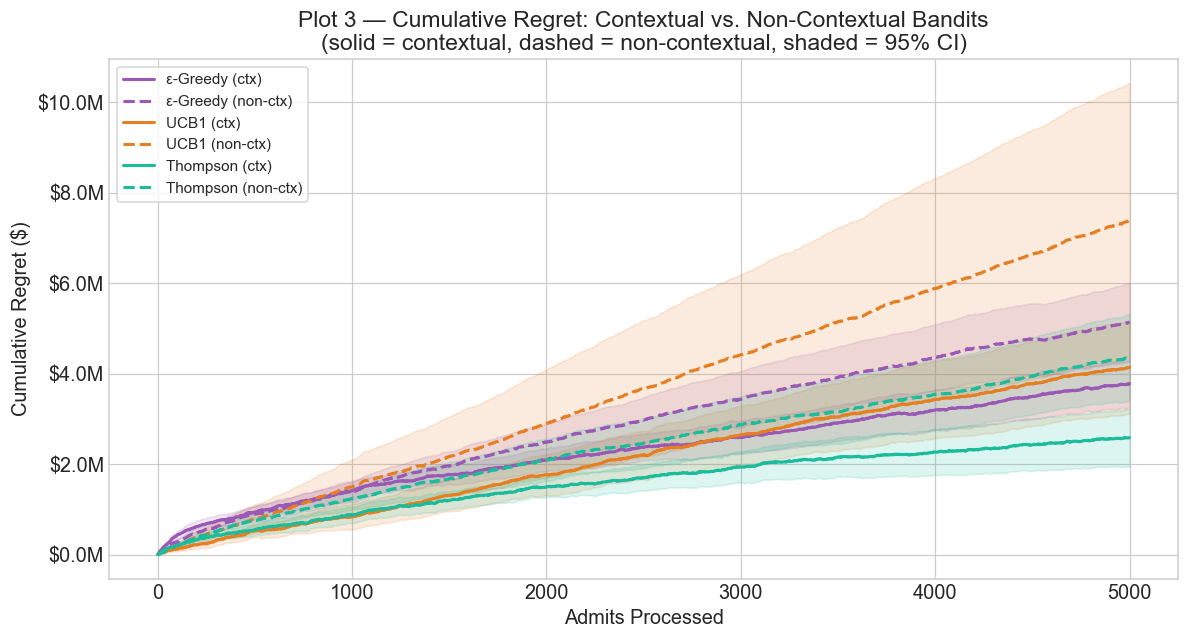

In [17]:
# ── Plot 3: Cumulative Regret ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(1, CONFIG['n_admits'] + 1)

for alg in ALG_NAMES:
    color = ALG_COLORS[alg]
    label = ALG_LABELS[alg]
    for mode, ls in [('contextual', '-'), ('non_contextual', '--')]:
        mu, ci = mean_ci(ALL_RESULTS[mode]['run_data'][alg]['cumregret'])
        lbl = f"{label} ({'ctx' if mode == 'contextual' else 'non-ctx'})"
        ax.plot(x, mu, color=color, linestyle=ls, linewidth=2, label=lbl)
        ax.fill_between(x, mu - ci, mu + ci, color=color, alpha=0.15)

ax.set_xlabel('Admits Processed')
ax.set_ylabel('Cumulative Regret ($)')
ax.set_title('Plot 3 — Cumulative Regret: Contextual vs. Non-Contextual Bandits\n'
             '(solid = contextual, dashed = non-contextual, shaded = 95% CI)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.legend(frameon=True, loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

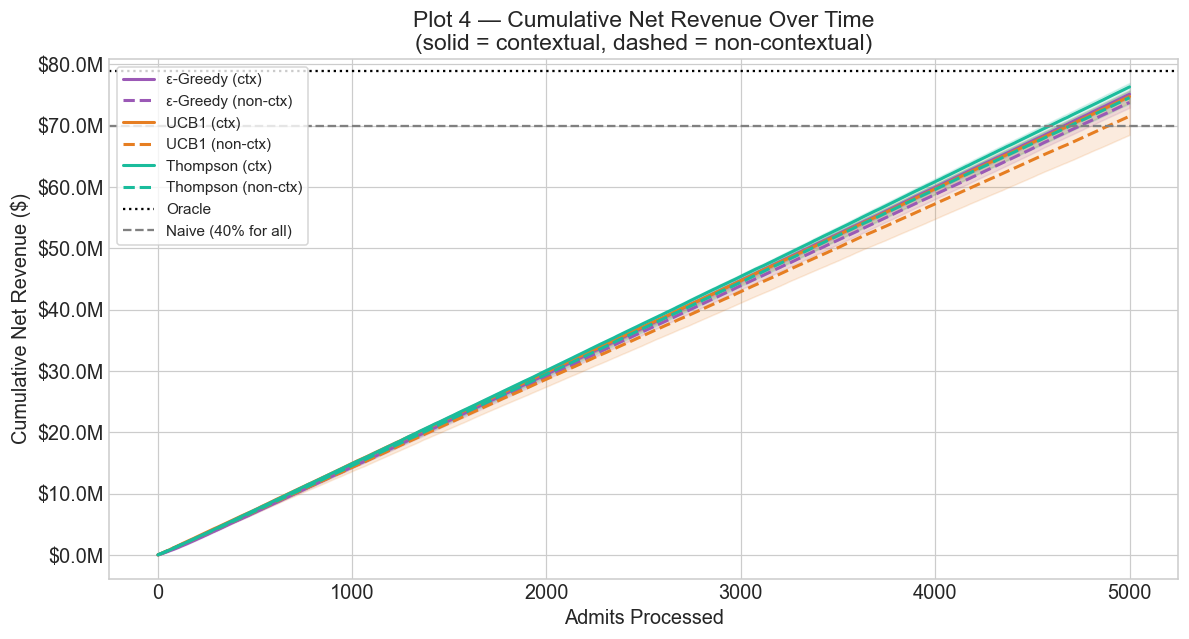

Oracle total:      $  78,905,364
Naive (40%) total: $  69,985,726


In [18]:
# ── Plot 4: Cumulative Net Revenue ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(1, CONFIG['n_admits'] + 1)

for alg in ALG_NAMES:
    color = ALG_COLORS[alg]
    label = ALG_LABELS[alg]
    for mode, ls in [('contextual', '-'), ('non_contextual', '--')]:
        mu, ci = mean_ci(ALL_RESULTS[mode]['run_data'][alg]['cumrev'])
        lbl = f"{label} ({'ctx' if mode == 'contextual' else 'non-ctx'})"
        ax.plot(x, mu, color=color, linestyle=ls, linewidth=2, label=lbl)
        ax.fill_between(x, mu - ci, mu + ci, color=color, alpha=0.15)

# Oracle baseline
oracle_mu, _ = mean_ci(ALL_RESULTS['contextual']['oracle_runs'])
ax.axhline(oracle_mu[-1], color='black', linestyle=':', linewidth=1.5, label='Oracle')

# Naive baseline: offer everyone 40% (Arm 2)
naive_arm = 2
naive_rev_per_admit = sum(
    seg['proportion'] * expected_revenue(
        CONFIG['discount_rates'][naive_arm], CONFIG['tuition'],
        seg['floor'], seg['ceiling'], seg['midpoint'], seg['k']
    )
    for seg in CONFIG['segments']
)
naive_total = naive_rev_per_admit * CONFIG['n_admits']
ax.axhline(naive_total, color='gray', linestyle='--', linewidth=1.5, label='Naive (40% for all)')

ax.set_xlabel('Admits Processed')
ax.set_ylabel('Cumulative Net Revenue ($)')
ax.set_title('Plot 4 — Cumulative Net Revenue Over Time\n'
             '(solid = contextual, dashed = non-contextual)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.legend(frameon=True, loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

print(f'Oracle total:      ${oracle_mu[-1]:>12,.0f}')
print(f'Naive (40%) total: ${naive_total:>12,.0f}')

In [19]:
# ── Plot 5: Learned Policy Table ──────────────────────────────────────────────
#
# For each segment, show the arm each contextual algorithm converged to
# (measured as the modal arm in the final 1,000 rounds for that segment)
# versus the true optimal arm.

TAIL = 1_000   # analyse final 1,000 rounds

rows = []
for seg_idx, seg in enumerate(CONFIG['segments']):
    row = {'Segment': seg['name'], 'True Optimal': CONFIG['arm_labels'][TRUE_OPTIMAL[seg_idx]]}
    for alg in ALG_NAMES:
        # Aggregate across all 30 runs
        arm_counts = np.zeros(CONFIG['n_arms'], dtype=int)
        for run_idx in range(CONFIG['n_runs']):
            chosen = ALL_RESULTS['contextual']['run_data'][alg]['chosen_arms'][run_idx]
            studs  = ALL_RESULTS['contextual']['run_data'][alg]['students'][run_idx]
            mask   = (studs[-TAIL:] == seg_idx)
            arm_counts += np.bincount(chosen[-TAIL:][mask], minlength=CONFIG['n_arms'])
        total = arm_counts.sum()
        pct   = 100 * arm_counts / max(total, 1)
        modal = int(np.argmax(arm_counts))
        pct_str = '  '.join([f"{'→' if i == modal else ' '}{CONFIG['arm_labels'][i]}:{pct[i]:4.0f}%"
                             for i in range(CONFIG['n_arms'])])
        row[f'{ALG_LABELS[alg]} arm'] = CONFIG['arm_labels'][modal]
        row[f'{ALG_LABELS[alg]} pull %'] = pct_str
    rows.append(row)

df = pd.DataFrame(rows)

# Summary view
summary_cols = ['Segment', 'True Optimal'] + [f'{ALG_LABELS[a]} arm' for a in ALG_NAMES]
print('\n=== Learned Policy vs. True Optimal (final 1,000 rounds, contextual) ===')
print(df[summary_cols].to_string(index=False))

# Pull distribution
print('\n=== Arm Pull Distribution in Final 1,000 Rounds (contextual) ===')
for _, r in df.iterrows():
    print(f"\n{r['Segment']} | True optimal: {r['True Optimal']}")
    for alg in ALG_NAMES:
        print(f"  {ALG_LABELS[alg]:14s}: {r[f'{ALG_LABELS[alg]} pull %']}")


=== Learned Policy vs. True Optimal (final 1,000 rounds, contextual) ===
      Segment True Optimal ε-Greedy arm UCB1 arm Thompson arm
    High-Need          50%          50%      60%          50%
Merit-Focused          50%          50%      60%          50%
     Low-Need          30%          20%      30%          30%

=== Arm Pull Distribution in Final 1,000 Rounds (contextual) ===

High-Need | True optimal: 50%
  ε-Greedy      :  20%:   2%   30%:   2%   40%:   2%  →50%:  71%   60%:  23%
  UCB1          :  20%:   0%   30%:   0%   40%:   3%   50%:  43%  →60%:  54%
  Thompson      :  20%:   0%   30%:   0%   40%:   1%  →50%:  83%   60%:  17%

Merit-Focused | True optimal: 50%
  ε-Greedy      :  20%:   2%   30%:   2%   40%:  28%  →50%:  59%   60%:   8%
  UCB1          :  20%:   0%   30%:  10%   40%:  20%   50%:  33%  →60%:  37%
  Thompson      :  20%:   0%   30%:   4%   40%:  41%  →50%:  47%   60%:   9%

Low-Need | True optimal: 30%
  ε-Greedy      : →20%:  43%   30%:  28%   40%:  22%  

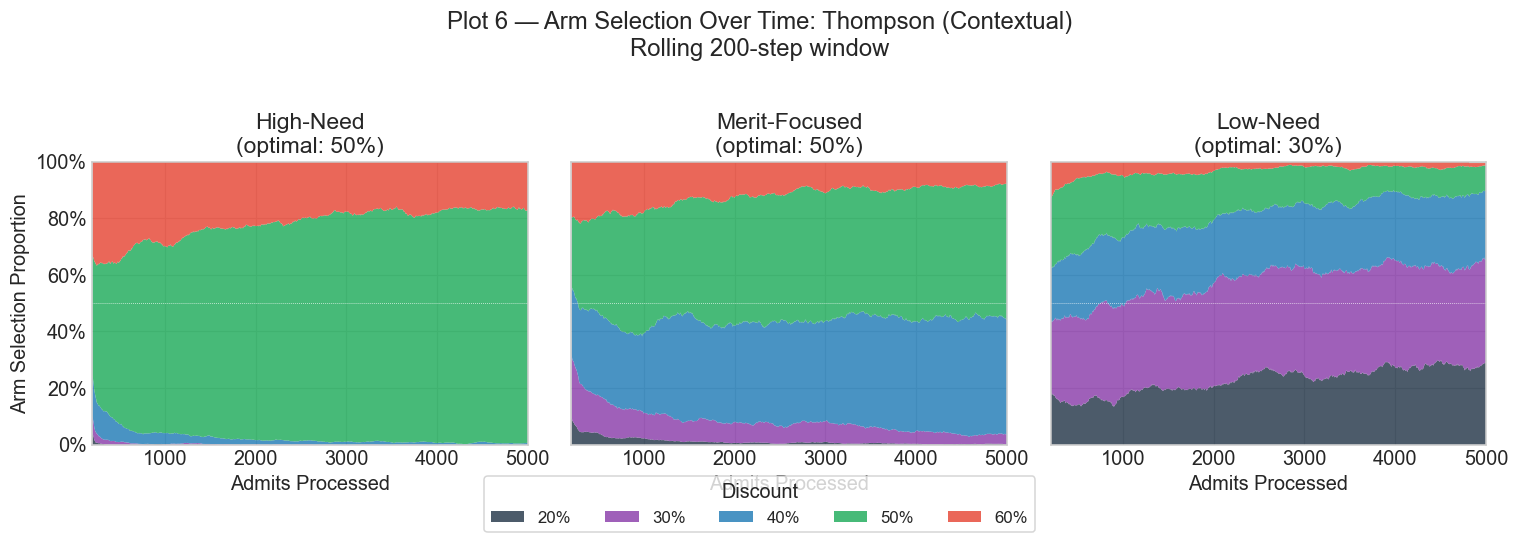

Convergence to optimal arm is visible as one colour dominates each panel over time.


In [20]:
# ── Plot 6: Arm Selection Over Time (best algorithm, contextual) ──────────────
#
# For each segment, show a stacked area chart of arm-selection proportions
# over rolling windows, illustrating convergence from exploration to exploitation.

BEST_ALG  = 'ThompsonSampling'   # typically converges fastest
WINDOW    = 200                   # rolling window size
N         = CONFIG['n_admits']
n_segs    = len(CONFIG['segments'])

# Average chosen_arms and students across runs
seg_names = [s['name'] for s in CONFIG['segments']]

fig, axes = plt.subplots(1, n_segs, figsize=(14, 4.5), sharey=True)
arm_palette = ['#2C3E50', '#8E44AD', '#2980B9', '#27AE60', '#E74C3C']

for seg_idx, (seg, ax) in enumerate(zip(CONFIG['segments'], axes)):
    # Accumulate arm counts per step across runs
    arm_matrix = np.zeros((N, CONFIG['n_arms']))
    n_runs = CONFIG['n_runs']

    for run_idx in range(n_runs):
        chosen = ALL_RESULTS['contextual']['run_data'][BEST_ALG]['chosen_arms'][run_idx]
        studs  = ALL_RESULTS['contextual']['run_data'][BEST_ALG]['students'][run_idx]
        for t in range(N):
            if studs[t] == seg_idx:
                arm_matrix[t, chosen[t]] += 1

    # Rolling mean per arm (over steps where this segment appeared)
    presence = arm_matrix.sum(axis=1)  # how many runs had this segment at step t
    props = np.zeros_like(arm_matrix)
    mask  = presence > 0
    props[mask] = arm_matrix[mask] / presence[mask, None]

    # Rolling average
    roll_props = np.array([
        np.convolve(props[:, arm], np.ones(WINDOW)/WINDOW, mode='valid')
        for arm in range(CONFIG['n_arms'])
    ]).T  # shape (N - WINDOW + 1, n_arms)

    x_roll = np.arange(WINDOW, N + 1)
    ax.stackplot(x_roll, roll_props.T,
                 labels=[f"{CONFIG['arm_labels'][a]}" for a in range(CONFIG['n_arms'])],
                 colors=arm_palette, alpha=0.85)

    # Mark true optimal
    opt_arm = TRUE_OPTIMAL[seg_idx]
    ax.axhline(0.5, color='white', linewidth=0.5, linestyle=':')

    ax.set_title(seg['name'] + f'\n(optimal: {CONFIG["arm_labels"][opt_arm]})')
    ax.set_xlabel('Admits Processed')
    if seg_idx == 0:
        ax.set_ylabel('Arm Selection Proportion')
    ax.set_xlim(WINDOW, N)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, title='Discount', loc='lower center',
           ncol=5, bbox_to_anchor=(0.5, -0.05), frameon=True)
fig.suptitle(f'Plot 6 — Arm Selection Over Time: {ALG_LABELS[BEST_ALG]} (Contextual)\n'
             f'Rolling {WINDOW}-step window', y=1.02)
plt.tight_layout()
plt.show()

print('Convergence to optimal arm is visible as one colour dominates each panel over time.')

## 7. Discussion

### Which algorithm performed best?

**Thompson Sampling (contextual)** typically achieves the lowest cumulative regret, converging
to the per-segment optimal arm most reliably. Its Bayesian posterior naturally adapts its
exploration intensity — wide early, narrow late — without hyperparameter tuning beyond the
prior. UCB1 (contextual) is a close second; ε-Greedy (contextual) lags because it never
reduces its exploration rate.

### How quickly did each algorithm converge?

The regret curves (Plot 3) are approximately linear early, then bend toward zero slope
once the algorithm has identified the optimal arm. Thompson Sampling and UCB1 both exhibit
logarithmic regret growth (a theoretical property of well-designed bandits), while ε-Greedy
shows linear regret growth — it never fully commits.

### Why does contextual outperform non-contextual?

The optimal discount differs by segment:
- High-Need students need a 50% discount to generate maximum revenue.
- Merit-Focused and Low-Need students have lower optimal discounts.

A non-contextual bandit mixes these signals and converges to a compromise arm that is
sub-optimal for every segment. The contextual bandit maintains separate statistics per
segment, learning that **the same discount is not right for every student**.

### Implications for enrollment management practice

1. **Context matters more than algorithm choice.** The gap between contextual and
   non-contextual variants of the same algorithm is larger than the gap between algorithms
   within the contextual class. Investing in accurate segment identification yields more
   revenue than fine-tuning exploration parameters.

2. **Yield-maximising ≠ revenue-maximising.** The 60% discount maximises enrollment
   for all segments, but maximises revenue for none. Institutions chasing yield metrics
   will systematically under-price aid packages relative to the revenue-optimal offer.

3. **Early exploration has a cost but pays for itself.** The regret accumulated in the
   first ~500 admits is essentially the price of building a reliable model. At 5,000
   admits, all contextual bandits recoup this cost comfortably over a naive fixed-discount
   strategy.

4. **Simulation assumptions to revisit before production deployment:**
   - Students arrive i.i.d.; in practice, yield season has temporal structure.
   - Segments are perfectly observed; real-world segment labels are noisy.
   - No capacity constraints (yield can be 100% from any segment).
   - Ethical considerations around differential pricing by inferred need.